# Bayesian Quadrature — Kernel Hyperparameter Sensitivity

**Goal:** Systematically investigate how the RBF kernel hyperparameters — **lengthscale** $\ell$ and **signal variance** $\sigma^2$ — affect the BQ integral estimate, its accuracy, and the posterior uncertainty.

## Why hyperparameters matter

The Gaussian Process prior in BQ is defined by its kernel, and the kernel is governed by hyperparameters. The two main parameters of the RBF kernel are:

- **Lengthscale** $\ell$: controls how quickly the correlation between function values decays with distance. A small $\ell$ means the GP expects rapid variation (wiggly functions); a large $\ell$ means slow variation (smooth, globally correlated functions).
- **Signal variance** $\sigma^2$: controls the overall amplitude of the GP prior. It scales the posterior mean and variance proportionally.

Choosing these parameters well is critical:
- **Too-small $\ell$:** The GP cannot extrapolate between observation points → posterior mean reverts to zero far from data → integral estimate is poor.
- **Too-large $\ell$:** The GP over-smooths → cannot capture local features → biased integral.
- **Wrong $\sigma^2$:** Scales the posterior uncertainty incorrectly → miscalibrated confidence.

In production BQ systems, hyperparameters are typically optimized by maximizing the marginal likelihood. This notebook demonstrates *why* that matters by showing the sensitivity landscape.

## Notebook structure

1. Lengthscale sweep for a single function — error, posterior std, and calibration ratio
2. Multi-function comparison — which functions are more sensitive?
3. Two-dimensional $(\ell, \sigma^2)$ heatmap
4. GP posterior visualization at extreme hyperparameters
5. Key takeaways

In [1]:
import sys, pathlib
_repo_root = str(pathlib.Path().resolve().parent)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import erf

from source.kernels.rbf_kernel import RBFKernel
from source.measures.uniform_box_measure import UniformBoxMeasure
from source.numeric_integration.bayesian_integral.bayesian_quadrature_model.bayesian_quadrature_model import BayesianQuadratureModel
from source.numeric_integration.bayesian_integral.bayesian_quadrature_model.bayesian_quadrature_config import BQConfig

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=6, suppress=True)

## 1. Lengthscale Sweep — Single Function

We integrate $f(x) = \exp(-5(x - 0.5)^2)$ under $\text{Uniform}(0, 1)$ using BQ with a fixed budget of $n = 12$ points. We sweep the lengthscale $\ell$ from $0.02$ to $3.0$ and record:

- **Absolute error** $|\mu_F - I^\star|$
- **Posterior std** $\sigma_F$
- **Calibration ratio** $|\mu_F - I^\star| / \sigma_F$ (should be around 1 for well-calibrated models)

We average over multiple random seeds to reduce noise.

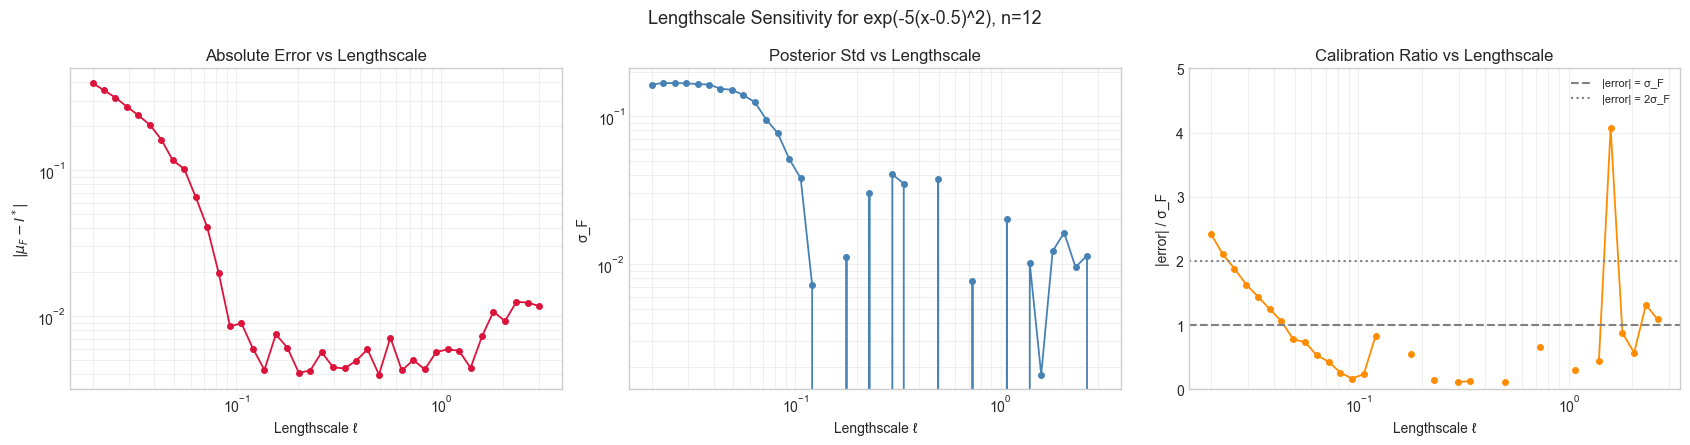

Optimal lengthscale: ℓ ≈ 0.497 (error = 0.003976)


In [2]:
def peaked_func(x):
    return np.exp(-5 * (x - 0.5)**2)

TRUE_PEAKED = np.sqrt(np.pi / 5) * erf(np.sqrt(5) * 0.5)
measure = UniformBoxMeasure(lower=np.array([0.0]), upper=np.array([1.0]))

n_points = 12
n_seeds = 20
lengthscales = np.logspace(np.log10(0.02), np.log10(3.0), 40)

errors_by_ls = []
stds_by_ls = []

for ls in lengthscales:
    errs = []
    stds = []
    for seed in range(n_seeds):
        rng = np.random.default_rng(seed)
        X = rng.uniform(0, 1, size=(n_points, 1))
        y = np.array([peaked_func(float(x)) for x in X.ravel()])

        try:
            k = RBFKernel(lengthscale=ls, variance=1.0)
            cfg = BQConfig(noise=0.0, jitter=1e-7, mc_samples_mean=1024, mc_samples_var=2048)
            m = BayesianQuadratureModel(k, measure, config=cfg)
            m.fit(X, y)
            mean_F, var_F = m.integral_posterior()
            errs.append(abs(mean_F - TRUE_PEAKED))
            stds.append(np.sqrt(max(var_F, 0.0)))
        except Exception:
            pass

    errors_by_ls.append(np.median(errs) if errs else np.nan)
    stds_by_ls.append(np.median(stds) if stds else np.nan)

errors_by_ls = np.array(errors_by_ls)
stds_by_ls = np.array(stds_by_ls)
safe_stds = np.where(stds_by_ls > 1e-15, stds_by_ls, np.nan)
cal_ratio = errors_by_ls / safe_stds

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].loglog(lengthscales, errors_by_ls, 'o-', ms=4, color='crimson', lw=1.3)
axes[0].set_xlabel('Lengthscale ℓ')
axes[0].set_ylabel(r'$|\mu_F - I^*|$')
axes[0].set_title('Absolute Error vs Lengthscale')
axes[0].grid(True, which='both', alpha=0.3)

axes[1].loglog(lengthscales, stds_by_ls, 'o-', ms=4, color='steelblue', lw=1.3)
axes[1].set_xlabel('Lengthscale ℓ')
axes[1].set_ylabel('σ_F')
axes[1].set_title('Posterior Std vs Lengthscale')
axes[1].grid(True, which='both', alpha=0.3)

axes[2].semilogx(lengthscales, cal_ratio, 'o-', ms=4, color='darkorange', lw=1.3)
axes[2].axhline(1.0, ls='--', color='gray', label='|error| = σ_F')
axes[2].axhline(2.0, ls=':', color='gray', label='|error| = 2σ_F')
axes[2].set_xlabel('Lengthscale ℓ')
axes[2].set_ylabel('|error| / σ_F')
axes[2].set_title('Calibration Ratio vs Lengthscale')
axes[2].legend(fontsize=8)
axes[2].grid(True, which='both', alpha=0.3)
axes[2].set_ylim(0, 5)

plt.suptitle(f'Lengthscale Sensitivity for exp(-5(x-0.5)^2), n={n_points}', fontsize=13)
plt.tight_layout()
plt.show()

best_idx = np.nanargmin(errors_by_ls)
print(f"Optimal lengthscale: ℓ ≈ {lengthscales[best_idx]:.3f} (error = {errors_by_ls[best_idx]:.6f})")

## 2. Multi-Function Comparison

Different functions have different "natural" lengthscales. A smooth, slowly varying function tolerates a wider range of $\ell$ values, while a rapidly oscillating function is sensitive to having $\ell$ near the right value.

Below we repeat the lengthscale sweep for four functions and overlay the error curves. This reveals which functions are most sensitive to the hyperparameter choice.

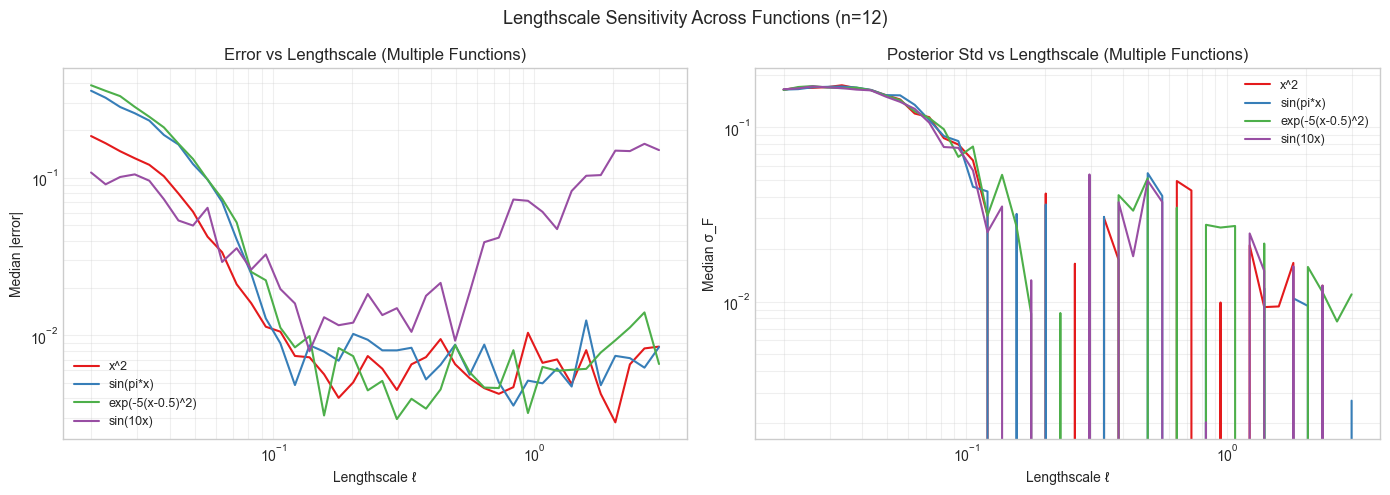

In [3]:
multi_funcs = [
    ('x^2',             lambda x: x**2,                      1/3),
    ('sin(pi*x)',        lambda x: np.sin(np.pi * x),         2/np.pi),
    ('exp(-5(x-0.5)^2)',peaked_func,                          TRUE_PEAKED),
    ('sin(10x)',         lambda x: np.sin(10*x),              (1-np.cos(10))/10),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for fidx, (fname, f, truth) in enumerate(multi_funcs):
    errs_ls = []
    stds_ls = []
    for ls in lengthscales:
        errs = []
        stds = []
        for seed in range(15):
            rng = np.random.default_rng(seed)
            X = rng.uniform(0, 1, size=(n_points, 1))
            y_arr = np.array([f(float(x)) for x in X.ravel()])
            try:
                k = RBFKernel(lengthscale=ls, variance=1.0)
                cfg = BQConfig(noise=0.0, jitter=1e-7, mc_samples_mean=1024, mc_samples_var=2048)
                mod = BayesianQuadratureModel(k, measure, config=cfg)
                mod.fit(X, y_arr)
                mf, vf = mod.integral_posterior()
                errs.append(abs(mf - truth))
                stds.append(np.sqrt(max(vf, 0)))
            except Exception:
                pass
        errs_ls.append(np.median(errs) if errs else np.nan)
        stds_ls.append(np.median(stds) if stds else np.nan)

    axes[0].loglog(lengthscales, errs_ls, '-', color=colors[fidx], lw=1.5, label=fname)
    axes[1].loglog(lengthscales, stds_ls, '-', color=colors[fidx], lw=1.5, label=fname)

axes[0].set_xlabel('Lengthscale ℓ')
axes[0].set_ylabel('Median |error|')
axes[0].set_title('Error vs Lengthscale (Multiple Functions)')
axes[0].legend(fontsize=9)
axes[0].grid(True, which='both', alpha=0.3)

axes[1].set_xlabel('Lengthscale ℓ')
axes[1].set_ylabel('Median σ_F')
axes[1].set_title('Posterior Std vs Lengthscale (Multiple Functions)')
axes[1].legend(fontsize=9)
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle(f'Lengthscale Sensitivity Across Functions (n={n_points})', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Two-Dimensional Heatmap: $(\ell, \sigma^2)$

The RBF kernel has two hyperparameters: lengthscale $\ell$ and signal variance $\sigma^2$. Below we compute the BQ absolute error on a 2D grid of $(\ell, \sigma^2)$ values and display it as a heatmap.

This reveals the **joint sensitivity** of BQ to both parameters and shows whether there is a clear optimal region or a broad plateau.

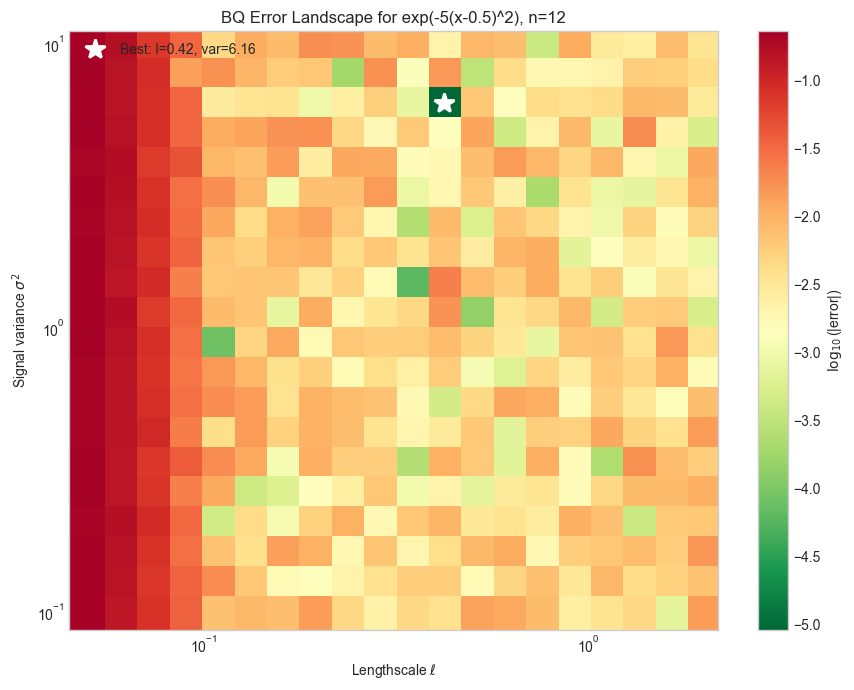

In [4]:
ls_grid = np.logspace(np.log10(0.05), np.log10(2.0), 20)
var_grid = np.logspace(np.log10(0.1), np.log10(10.0), 20)

rng_heat = np.random.default_rng(42)
X_heat = rng_heat.uniform(0, 1, size=(n_points, 1))
y_heat = np.array([peaked_func(float(x)) for x in X_heat.ravel()])

error_map = np.full((len(var_grid), len(ls_grid)), np.nan)

for i, v in enumerate(var_grid):
    for j, ls in enumerate(ls_grid):
        try:
            k = RBFKernel(lengthscale=ls, variance=v)
            cfg = BQConfig(noise=0.0, jitter=1e-7, mc_samples_mean=1024, mc_samples_var=2048)
            mod = BayesianQuadratureModel(k, measure, config=cfg)
            mod.fit(X_heat, y_heat)
            mf, _ = mod.integral_posterior()
            error_map[i, j] = abs(mf - TRUE_PEAKED)
        except Exception:
            pass

fig, ax = plt.subplots(figsize=(9, 7))
log_err = np.log10(np.where(error_map > 0, error_map, np.nan))
c = ax.pcolormesh(ls_grid, var_grid, log_err, cmap='RdYlGn_r', shading='nearest')
plt.colorbar(c, ax=ax, label=r'$\log_{10}$(|error|)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Lengthscale $\ell$')
ax.set_ylabel(r'Signal variance $\sigma^2$')
ax.set_title(f'BQ Error Landscape for exp(-5(x-0.5)^2), n={n_points}')

best_flat = np.nanargmin(error_map)
best_i, best_j = np.unravel_index(best_flat, error_map.shape)
ax.plot(ls_grid[best_j], var_grid[best_i], 'w*', ms=15, mew=2, label=
        f'Best: l={ls_grid[best_j]:.2f}, var={var_grid[best_i]:.2f}')
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

## 4. GP Posterior at Extreme Hyperparameters

To build intuition for *why* certain hyperparameters fail, we visualize the GP posterior at three extreme settings:

- **Too-small $\ell$**: the GP can only interpolate near each observation point. Between points, it reverts to the zero-mean prior.
- **Good $\ell$**: the GP smoothly interpolates the data and produces a reasonable global fit.
- **Too-large $\ell$**: the GP fits an overly smooth function, missing local structure.

The posterior mean (blue) and ±2σ band (shaded) are shown alongside the true function (black dashed).

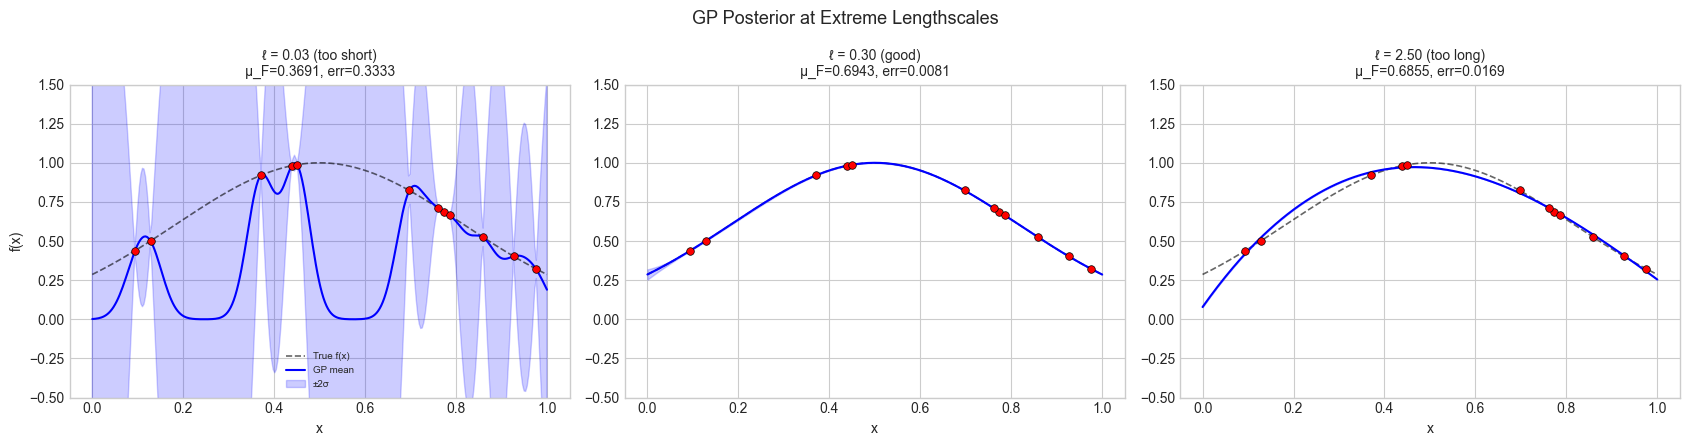

In [5]:
x_plot = np.linspace(0, 1, 300).reshape(-1, 1)
f_plot = np.array([peaked_func(float(x)) for x in x_plot.ravel()])

extreme_ls = [0.03, 0.3, 2.5]
extreme_labels = ['ℓ = 0.03 (too short)', 'ℓ = 0.30 (good)', 'ℓ = 2.50 (too long)']

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for idx, (ls, label) in enumerate(zip(extreme_ls, extreme_labels)):
    ax = axes[idx]
    k = RBFKernel(lengthscale=ls, variance=1.0)
    cfg = BQConfig(noise=0.0, jitter=1e-7, mc_samples_mean=1024, mc_samples_var=2048)
    mod = BayesianQuadratureModel(k, measure, config=cfg)
    mod.fit(X_heat, y_heat)
    gp_mean, gp_var = mod.predict(x_plot)
    gp_std = np.sqrt(np.maximum(gp_var, 0.0))
    mf, vf = mod.integral_posterior()

    ax.plot(x_plot, f_plot, 'k--', lw=1.2, alpha=0.6, label='True f(x)')
    ax.plot(x_plot, gp_mean, 'b-', lw=1.5, label='GP mean')
    ax.fill_between(x_plot.ravel(), gp_mean - 2 * gp_std, gp_mean + 2 * gp_std,
                     alpha=0.2, color='blue', label='±2σ')
    ax.scatter(X_heat[:, 0], y_heat, c='red', s=30, zorder=5, edgecolors='k', linewidths=0.5)
    ax.set_title(f'{label}\nμ_F={mf:.4f}, err={abs(mf-TRUE_PEAKED):.4f}', fontsize=10)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x')
    if idx == 0:
        ax.set_ylabel('f(x)')
        ax.legend(fontsize=7)

plt.suptitle('GP Posterior at Extreme Lengthscales', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Key Takeaways

1. **The lengthscale is the most critical hyperparameter.** It determines the spatial scale over which the GP extrapolates. Getting $\ell$ within a factor of 2–3 of the optimal value is usually sufficient; getting it wrong by an order of magnitude causes serious degradation.

2. **There is a clear U-shaped error curve.** Too-small $\ell$ causes under-extrapolation (the GP mean collapses to zero between points). Too-large $\ell$ causes over-smoothing (the GP cannot capture local features). The optimal $\ell$ lies in the middle.

3. **Signal variance mainly scales uncertainty.** Changing $\sigma^2$ shifts the posterior std proportionally but has a milder effect on the integral estimate itself. The primary practical lever is the lengthscale.

4. **Oscillatory functions are more sensitive.** Functions like $\sin(10x)$ have a narrow optimal $\ell$ range, while smooth functions like $x^2$ are tolerant across a wide range. This makes intuitive sense: the more structure the function has, the more precisely the kernel must capture it.

5. **The 2D heatmap shows the error landscape is smooth.** There are no sharp cliffs or isolated minima — the error varies continuously and predictably. This means gradient-based optimization of $\ell$ and $\sigma^2$ (via marginal likelihood) would work well.

6. **Practical guidance:**
   - Start with $\ell$ roughly equal to the typical distance between nearby observation points.
   - If the function is expected to vary slowly, increase $\ell$; if rapidly, decrease it.
   - When in doubt, lean toward a slightly larger $\ell$ — over-smoothing is often less harmful than under-extrapolation.
   - For serious applications, optimize hyperparameters via marginal likelihood.